# 5.09

Heat capacity of a solid
a. we need to integrate this. it says to use gaussian quadrature so we'll try that but we'll also maybe try simpson's rule

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxwab

In [8]:
import ph390 as ph

In [3]:
# setting up constants
V = 0.001
rho = 6.022e28
kB = 1.38*10**(-23)
thD = 428

In [4]:
def f(x):
    return(x**4*np.exp(x)/(np.exp(x)-1)**2)

Let's look at that function first just to get a sense for what it looks like.

/tmp/ipykernel_767959/1435524251.py:2: RuntimeWarning: invalid value encountered in divide
  return(x**4*np.exp(x)/(np.exp(x)-1)**2)


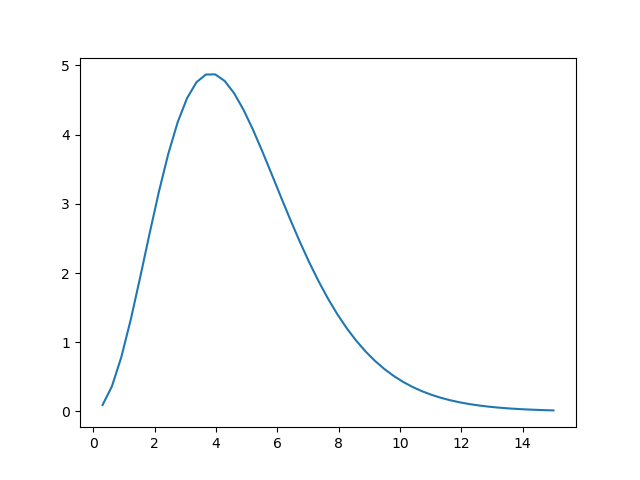

In [5]:
fig0, ax0 = plt.subplots()
x = np.linspace(0,15)
y = f(x)
ax0.plot(x, y)

So that is the function that we want to integrate which is inside a function of T. So the function itself is an integral of part of the curve we see above.

In [17]:
def cv(T):
    N = 50
    x, w = ph.gaussxwab(N, 0, thD/T)
    s = 0.0
    for k in range(N):
        s = s + w[k]*f(x[k])
    return(9*V*rho*kB*((T/thD)**3)*s)

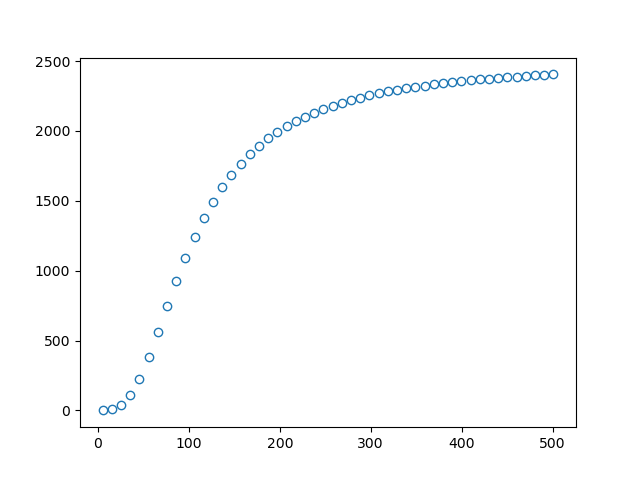

In [18]:
fig, ax = plt.subplots()

t = np.linspace(5, 501)
c = []
for i in t:
    c.append(cv(i))

ax.plot(t, c, 'o', mfc='none')

what if i tried to do simpson's rule here? oh but plugging in 0 is problematic for that denominator...

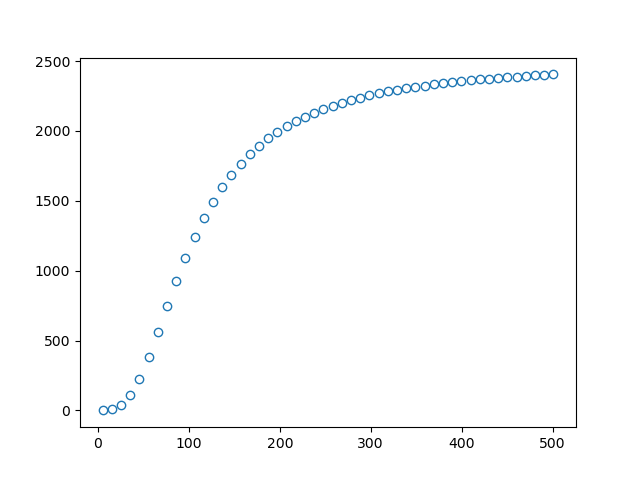

In [16]:
def cv_a(T):
    N = 50
    s = 0.0
    s = ph.simp(f, 0.01, thD/T, N) # i can only get near to zero, but at zero
    return(9*V*rho*kB*((T/thD)**3)*s)

fig, ax = plt.subplots()

t = np.linspace(5, 501)
c = []
for i in t:
    c.append(cv_a(i))

ax.plot(t, c, 'o', mfc='none')